In [3]:
import pandas as pd

yalp_photos_json_path = "C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos.json"

photos_df = pd.read_json(yalp_photos_json_path, lines=True)

In [6]:
photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [8]:
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [10]:
# Check nulls and empty strings
null_photo_id = photos_df['photo_id'].isnull().sum()
empty_photo_id = (photos_df['photo_id'].astype(str).str.strip() == '').sum()

null_label = photos_df['label'].isnull().sum()
empty_label = (photos_df['label'].astype(str).str.strip() == '').sum()

print(f"Null photo_id: {null_photo_id}")
print(f"Empty photo_id: {empty_photo_id}")
print(f"Null label: {null_label}")
print(f"Empty label: {empty_label}")

Null photo_id: 0
Empty photo_id: 0
Null label: 0
Empty label: 0


In [12]:
# Count of businesses per label
label_counts_businesses = photos_df['label'].value_counts().sort_index()

print("Businesses per label:")
print(label_counts_businesses)

Businesses per label:
label
drink       15670
food       108152
inside      56031
menu         1678
outside     18569
Name: count, dtype: int64


Businesses per label:
label
drink       15670
food       108152
inside      56031
menu         1678
outside     18569
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_29820\3077068713.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts_businesses.index, y=label_counts_businesses.values, palette='pastel')


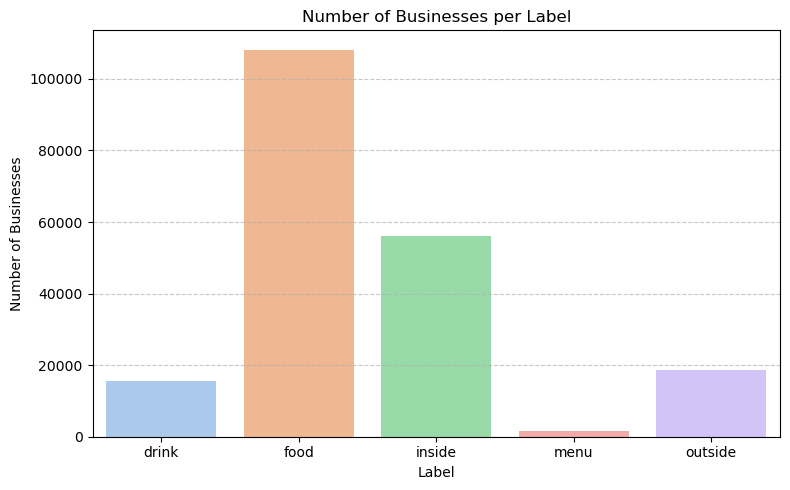

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count businesses per label
label_counts_businesses = photos_df['label'].value_counts().sort_index()

# Display counts
print("Businesses per label:")
print(label_counts_businesses)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts_businesses.index, y=label_counts_businesses.values, palette='pastel')

plt.title("Number of Businesses per Label")
plt.xlabel("Label")
plt.ylabel("Number of Businesses")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [15]:
base_image_countainer_folder_path = "C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\"

In [18]:
import os
from PIL import Image
import pandas as pd
from tqdm import tqdm

# Enable progress_apply in pandas
tqdm.pandas()

# Define image root path
image_root = r"C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos"

# Function to check if image file exists and is not corrupt
def is_valid_image(photo_id):
    path = os.path.join(image_root, f"{photo_id}.jpg")
    if not os.path.exists(path):
        return False
    try:
        with Image.open(path) as img:
            img.verify()  # Verify does not load full image, just checks integrity
        return True
    except Exception:
        return False

In [20]:
# Assuming your DataFrame is called df_photos and has a column 'photo_id'
photos_df['is_valid'] = photos_df['photo_id'].progress_apply(is_valid_image)

100%|█████████████████████████████████████████████████████████████████████████| 200100/200100 [06:44<00:00, 494.16it/s]


In [22]:
total = len(photos_df)
valid = photos_df['is_valid'].sum()
invalid = total - valid
percent_valid = (valid / total) * 100

print(f"Total images: {total}")
print(f"✅ Valid images: {valid}")
print(f"❌ Invalid (missing/corrupt): {invalid}")
print(f"📊 Percentage valid: {percent_valid:.2f}%")

Total images: 200100
✅ Valid images: 199994
❌ Invalid (missing/corrupt): 106
📊 Percentage valid: 99.95%


In [24]:
photos_df_valid = photos_df[photos_df['is_valid']].copy()

In [26]:
photos_df_valid['label'].value_counts().sort_index()

label
drink       15670
food       108047
inside      56030
menu         1678
outside     18569
Name: count, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split

# Pseudocode
#train_images = 90% of valid images
#eval_images  = 10% for FID / Inception Score
# Filter valid images first

train_df, fid_df = train_test_split(photos_df_valid, test_size=0.1, stratify=photos_df_valid['label'], random_state=42)

In [30]:
from PIL import Image

class ResizeWithPadding:
    def __init__(self, size, fill_color=(0, 0, 0)):
        self.size = size
        self.fill_color = fill_color

    def __call__(self, image):
        old_size = image.size  # (width, height)
        ratio = float(self.size) / max(old_size)
        new_size = tuple([int(x * ratio) for x in old_size])
        image = image.resize(new_size, Image.Resampling.LANCZOS)

        new_image = Image.new("RGB", (self.size, self.size), self.fill_color)
        paste_position = ((self.size - new_size[0]) // 2,
                          (self.size - new_size[1]) // 2)
        new_image.paste(image, paste_position)
        return new_image


In [32]:
from torchvision import transforms
import torchvision.transforms.functional as TF

# Apply resize with padding, then normalize
resize_transform = transforms.Compose([
    ResizeWithPadding(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Augmentation + Resize with padding
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    ResizeWithPadding(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


In [34]:
import os
from tqdm import tqdm
from PIL import Image
import shutil
import torchvision 

#) Source path of raw images
image_root = r"C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos"
# Destination path for balanced dataset
output_root_original = r"C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\Train1\\original_photos"
output_root_processed = r"C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\Train1\\processed_photos"

# Ensure folders exist
os.makedirs(output_root_original, exist_ok=True)
os.makedirs(output_root_processed, exist_ok=True)

# To store metadata of new dataset
balanced_records = []

# Target per label
TARGET = 5000

# Group images by label
grouped = train_df.groupby('label')

new_id_counter = 1

for label, group in grouped:
    print(f"📁 Processing label: {label} ({len(group)} images)")
    
    images_needed = TARGET
    used_ids = set()
    
    # Step 1: Copy real images (resized)
    for _, row in group.iterrows():
        if images_needed == 0:
            break
        photo_id = row['photo_id']
        src_path = os.path.join(image_root, f"{photo_id}.jpg")
        
        try:
            img = Image.open(src_path).convert("RGB")
            img_resized = resize_transform(img)
            #Save original image
            segrigated_path = os.path.join(output_root_original, f"{photo_id}.jpg")
            img.save(segrigated_path)
            # Save resized image
            new_filename = f"{label}_{new_id_counter}_{photo_id}.jpg"
            processed_path = os.path.join(output_root_processed, new_filename)
            torchvision.utils.save_image(img_resized, processed_path)
            balanced_records.append({
                'new_photo_id': new_filename.split('.')[0],
                'label': label,
                'original_photo_id': photo_id,
                'augmented': False
            })
            
            new_id_counter += 1
            images_needed -= 1
            used_ids.add(photo_id)
        except Exception as e:
            print(f"Skipping corrupt image: {photo_id}, error: {e}")
    
    # Step 2: Augment random images to fill remaining slots
    while images_needed > 0:
        row = group.sample(1).iloc[0]
        photo_id = row['photo_id']
        src_path = os.path.join(image_root, f"{photo_id}.jpg")
        try:
            img = Image.open(src_path).convert("RGB")
            img_aug = augment_transform(img)
            
            # Save augmented image
            new_filename = f"{label}_{new_id_counter}_aug.jpg"
            processed_path = os.path.join(output_root_processed, new_filename)
            torchvision.utils.save_image(img_aug, processed_path)
            
            balanced_records.append({
                'new_photo_id': new_filename.split('.')[0],
                'label': label,
                'original_photo_id': photo_id,
                'augmented': True
            })
            
            new_id_counter += 1
            images_needed -= 1
        except Exception as e:
            print(f"Augment failed for {photo_id}, error: {e}")

df_balanced = pd.DataFrame(balanced_records)
df_balanced.to_csv(r"C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\Train1\\processed_metadata.csv", index=False)

print("✅ Saved as CSV: processed_metadata.csv")


📁 Processing label: drink (14103 images)
📁 Processing label: food (97242 images)
📁 Processing label: inside (50427 images)
📁 Processing label: menu (1510 images)
📁 Processing label: outside (16712 images)
✅ Saved as CSV: processed_metadata.csv


In [36]:
import os
from tqdm import tqdm
from PIL import Image
import shutil
import torchvision 

#) Source path of raw images
image_root = r"C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos"
# Destination path for balanced dataset

output_root_original = r"C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\Test1\\original_photos"
output_root_processed = r"C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\Test1\\processed_photos"
# Ensure folders exist
os.makedirs(output_root_original, exist_ok=True)
os.makedirs(output_root_processed, exist_ok=True)

# To store metadata of new dataset
balanced_records = []

# Target per label
TARGET = 1000

# Group images by label
grouped = fid_df.groupby('label')

new_id_counter = 1

for label, group in grouped:
    print(f"📁 Processing label: {label} ({len(group)} images)")
    
    images_needed = TARGET
    used_ids = set()
    
    # Step 1: Copy real images (resized)
    for _, row in group.iterrows():
        if images_needed == 0:
            break
        photo_id = row['photo_id']
        src_path = os.path.join(image_root, f"{photo_id}.jpg")
        
        try:
            img = Image.open(src_path).convert("RGB")
            img_resized = resize_transform(img)
            #Save original image
            segrigated_path = os.path.join(output_root_original, f"{photo_id}.jpg")
            img.save(segrigated_path)
            # Save resized image
            new_filename = f"{label}_{new_id_counter}_{photo_id}.jpg"
            processed_path = os.path.join(output_root_processed, new_filename)
            torchvision.utils.save_image(img_resized, processed_path)
            balanced_records.append({
                'new_photo_id': new_filename.split('.')[0],
                'label': label,
                'original_photo_id': photo_id,
                'augmented': False
            })
            
            new_id_counter += 1
            images_needed -= 1
            used_ids.add(photo_id)
        except Exception as e:
            print(f"Skipping corrupt image: {photo_id}, error: {e}")
    ""
    # Step 2: Augment random images to fill remaining slots
    while images_needed > 0:
        row = group.sample(1).iloc[0]
        photo_id = row['photo_id']
        src_path = os.path.join(image_root, f"{photo_id}.jpg")
        try:
            img = Image.open(src_path).convert("RGB")
            img_aug = augment_transform(img)
            
            # Save augmented image
            new_filename = f"{label}_{new_id_counter}_aug.jpg"
            processed_path = os.path.join(output_root_processed, new_filename)
            torchvision.utils.save_image(img_aug, processed_path)
            
            balanced_records.append({
                'new_photo_id': new_filename.split('.')[0],
                'label': label,
                'original_photo_id': photo_id,
                'augmented': True
            })
            
            new_id_counter += 1
            images_needed -= 1
        except Exception as e:
            print(f"Augment failed for {photo_id}, error: {e}")

df_balanced = pd.DataFrame(balanced_records)
df_balanced.to_csv(r"C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\Test1\\processed_metadata.csv", index=False)

print("✅ Saved as CSV: processed_metadata.csv")


📁 Processing label: drink (1567 images)
📁 Processing label: food (10805 images)
📁 Processing label: inside (5603 images)
📁 Processing label: menu (168 images)
📁 Processing label: outside (1857 images)


OSError: Cannot save file into a non-existent directory: 'C:\PG AI and DS\Semester 3\Computer Vision AISC2008\Yelp-Photos\Yelp Photos\yelp_photos\Test1'

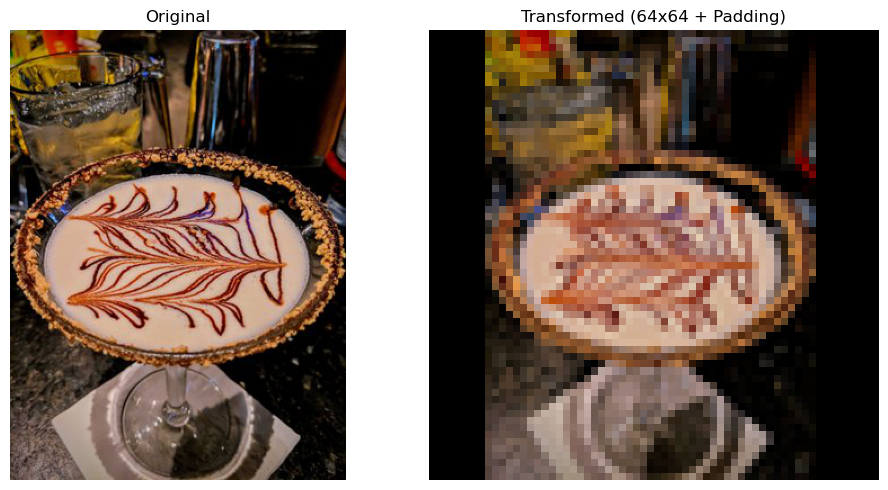

In [38]:
# Load an example image (change this to your path)
img_path = r"C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\__qwnab_ljzLZdiCbrkuTA.jpg"
original_img = Image.open(img_path).convert("RGB")

# Apply transform
transformed_tensor = resize_transform(original_img)

# Convert back to PIL for visualization (de-normalize first)
def denormalize(tensor):
    return tensor * 0.5 + 0.5  # Bring back to [0, 1] range

# Plot original vs transformed
plt.figure(figsize=(10, 5))

# Original
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original")
plt.axis("off")

# Transformed
plt.subplot(1, 2, 2)
transformed_img = denormalize(transformed_tensor).permute(1, 2, 0).clamp(0, 1)
plt.imshow(transformed_img)
plt.title("Transformed (64x64 + Padding)")
plt.axis("off")

plt.tight_layout()
plt.show()


In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import os
from PIL import Image


In [42]:

# Check for CUDA availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
from PIL import Image
import os
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [46]:
class FlatImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, 0  # dummy label

In [58]:
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import random

# Define transforms
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Load full dataset
dataset = FlatImageDataset(image_dir=image_dir, transform=transform)

# Sample 10,000 random indices
sample_size = 10000
total_size = len(dataset)
random_indices = random.sample(range(total_size), min(sample_size, total_size))

# Create subset dataset
sampled_dataset = Subset(dataset, random_indices)

# Dataloader
dataloader = DataLoader(sampled_dataset, batch_size=128, shuffle=True)

print("Dataloader ready. Total sampled images:", len(sampled_dataset))


Dataloader ready. Total sampled images: 10000


In [60]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, channels_img=3, features_g=64):
        super().__init__()
        self.gen = nn.Sequential(
            nn.ConvTranspose2d(z_dim, features_g * 8, 4, 1, 0),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 2, channels_img, 4, 2, 1),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.gen(x)

In [62]:
class Discriminator(nn.Module):
    def __init__(self, channels_img=3, features_d=64):
        super().__init__()
        self.disc = nn.Sequential(
            nn.Conv2d(channels_img, features_d, 4, 2, 1),       # 64 → 32
            nn.LeakyReLU(0.2),

            nn.Conv2d(features_d, features_d * 2, 4, 2, 1),      # 32 → 16
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2),

            nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1),  # 16 → 8
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2),

            nn.Conv2d(features_d * 4, 1, 4, 2, 1),               # 8 → 4
            nn.Sigmoid(),
        )

    def forward(self, x):
        out = self.disc(x)             # shape: [B, 1, 4, 4]
        out = out.mean([2, 3])         # average over spatial dims → shape: [B, 1]
        return out.view(-1)            # shape: [B]

In [64]:
z_dim = 100
lr = 2e-4
channels_img = 3
features_gen = 64
features_disc = 64

gen = Generator(z_dim, channels_img, features_gen).to(device)
disc = Discriminator(channels_img, features_disc).to(device)

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)

gen.apply(weights_init)
disc.apply(weights_init)

opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

criterion = nn.BCELoss()
print("Models initialized and ready.")

Models initialized and ready.


Epoch [1/50]  Loss D: 0.2909, Loss G: 1.2579  ⏱️ Time: 46.16 sec
Epoch [2/50]  Loss D: 0.1043, Loss G: 2.1723  ⏱️ Time: 25.43 sec
Epoch [3/50]  Loss D: 0.4589, Loss G: 1.3476  ⏱️ Time: 25.34 sec
Epoch [4/50]  Loss D: 0.1760, Loss G: 1.6037  ⏱️ Time: 25.50 sec
Epoch [5/50]  Loss D: 0.0220, Loss G: 3.6308  ⏱️ Time: 25.51 sec
Epoch [6/50]  Loss D: 0.0185, Loss G: 3.8452  ⏱️ Time: 25.08 sec
Epoch [7/50]  Loss D: 0.0158, Loss G: 4.0680  ⏱️ Time: 24.94 sec
Epoch [8/50]  Loss D: 0.0086, Loss G: 4.5549  ⏱️ Time: 25.30 sec
Epoch [9/50]  Loss D: 0.0086, Loss G: 4.6979  ⏱️ Time: 25.34 sec
Epoch [10/50]  Loss D: 0.0061, Loss G: 4.8892  ⏱️ Time: 26.54 sec
Epoch [11/50]  Loss D: 0.0046, Loss G: 5.2591  ⏱️ Time: 25.14 sec
Epoch [12/50]  Loss D: 0.0031, Loss G: 5.6310  ⏱️ Time: 30.12 sec
Epoch [13/50]  Loss D: 0.0026, Loss G: 5.7896  ⏱️ Time: 29.91 sec
Epoch [14/50]  Loss D: 0.0033, Loss G: 5.7336  ⏱️ Time: 30.31 sec
Epoch [15/50]  Loss D: 0.0020, Loss G: 6.1685  ⏱️ Time: 31.80 sec
Epoch [16/50]  Loss

C:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


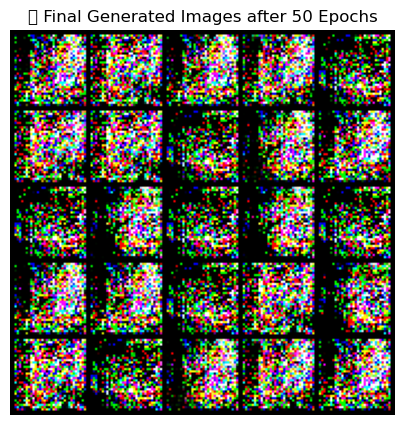

In [55]:
import time

epochs = 50
fixed_noise = torch.randn(64, z_dim, 1, 1).to(device)

for epoch in range(epochs):
    start_time = time.time()

    for batch_idx, (real, _) in enumerate(dataloader):
        real = real.to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size).to(device)
        fake_labels = torch.zeros(batch_size).to(device)

        # ---- Train Discriminator ----
        noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
        fake = gen(noise)

        disc_real = disc(real)
        lossD_real = criterion(disc_real, real_labels)

        disc_fake = disc(fake.detach())
        lossD_fake = criterion(disc_fake, fake_labels)

        lossD = (lossD_real + lossD_fake) / 2
        disc.zero_grad()
        lossD.backward()
        opt_disc.step()

        # ---- Train Generator ----
        output = disc(fake)
        lossG = criterion(output, real_labels)
        gen.zero_grad()
        lossG.backward()
        opt_gen.step()

    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{epochs}]  Loss D: {lossD:.4f}, Loss G: {lossG:.4f}  ⏱️ Time: {epoch_time:.2f} sec")

# Show final output at the end of training
with torch.no_grad():
    fake_images = gen(fixed_noise).detach().cpu()

grid = make_grid(fake_images[:25], normalize=True, nrow=5)
plt.figure(figsize=(5, 5))
plt.imshow(grid.permute(1, 2, 0))
plt.title("🖼️ Final Generated Images after 50 Epochs")
plt.axis('off')
plt.show()


In [61]:
import torch
import torch.nn.functional as F
import numpy as np
from torchvision.models import inception_v3
from scipy.linalg import sqrtm
import torch.nn as nn

# Load pretrained InceptionV3 model
inception_model = inception_v3(pretrained=True, transform_input=False).to(device)
inception_model.fc = nn.Identity()  # Use pool3 features

# Get inception features for a batch of images
def get_inception_features(imgs, model, batch_size=32):
    model.eval()
    features = []

    with torch.no_grad():
        for i in range(0, imgs.size(0), batch_size):
            batch = imgs[i:i+batch_size].to(device)
            batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
            output = model(batch)
            features.append(output.cpu().numpy())

    return np.concatenate(features, axis=0)

# Inception Score
def inception_score(imgs, model, splits=10):
    preds = get_inception_features(imgs, model)
    preds = F.softmax(torch.tensor(preds), dim=1).numpy()
    scores = []

    for i in range(splits):
        part = preds[i * (len(preds)//splits):(i + 1) * (len(preds)//splits)]
        py = np.mean(part, axis=0)
        kl_div = part * (np.log(part + 1e-6) - np.log(py + 1e-6))
        scores.append(np.exp(np.mean(np.sum(kl_div, axis=1))))

    return np.mean(scores), np.std(scores)

# FID Score
def calculate_fid(real_imgs, fake_imgs, model):
    act1 = get_inception_features(real_imgs, model)
    act2 = get_inception_features(fake_imgs, model)
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

# ==== Evaluation ====

# Sample real images from dataloader
real_imgs, _ = next(iter(dataloader))
real_imgs = real_imgs[:64].to(device)

# Generate fake images (assuming you have trained generator `gen`)
with torch.no_grad():
    z = torch.randn(64, 100, 1, 1).to(device)  # Adjust z_dim if different
    gen_imgs = gen(z)

# Evaluate
is_mean, is_std = inception_score(gen_imgs, inception_model)
fid_value = calculate_fid(real_imgs, gen_imgs, inception_model)

print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
print(f"FID Score: {fid_value:.4f}")


C:\Users\Admin\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Inception Score: 1.0168 ± 0.0023
FID Score: 354.7016


✅ Key Observations
📉 Discriminator Loss (D Loss)
Starts at 0.29 and quickly drops to near zero (~0.0001) by epoch 20.

This means the Discriminator is overpowering the Generator — it learns to classify fake images too easily.

📈 Generator Loss (G Loss)
Starts at 1.25, increases progressively up to ~9.27, which seems high.

This typically means the Generator is struggling — it’s being penalized heavily by a too-strong Discriminator.

🎯 Evaluation Metrics
Inception Score (IS): 1.0168 ± 0.0023 → extremely low. (Typical good IS: >6 for ImageNet-level data)

FID Score: 354.7016 → very high. (Good FID: <50, ideally <10)

In [63]:
import torch
import torch.nn as nn

# Generator (unchanged)
class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# Simplified Discriminator (only 2 layers)
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, 1, 4, 2, 1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

# Initialize models
device = "cuda" if torch.cuda.is_available() else "cpu"
nz = 100  # Latent vector size

G = Generator(nz=nz).to(device)
D = Discriminator().to(device)

# Optimizers
optimizer_D = torch.optim.Adam(D.parameters(), lr=1e-4, betas=(0.5, 0.999))
optimizer_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))


Epoch [1/50]  Loss D: 0.2926, Loss G: 1.2940  ⏱️ Time: 42.00 sec
Epoch [2/50]  Loss D: 0.0974, Loss G: 2.2666  ⏱️ Time: 24.96 sec
Epoch [3/50]  Loss D: 0.0419, Loss G: 3.0526  ⏱️ Time: 24.93 sec
Epoch [4/50]  Loss D: 0.3268, Loss G: 1.5264  ⏱️ Time: 24.90 sec
Epoch [5/50]  Loss D: 0.0292, Loss G: 3.4228  ⏱️ Time: 25.26 sec
Epoch [6/50]  Loss D: 0.0175, Loss G: 3.8908  ⏱️ Time: 24.70 sec
Epoch [7/50]  Loss D: 0.0143, Loss G: 4.1366  ⏱️ Time: 24.74 sec
Epoch [8/50]  Loss D: 0.0090, Loss G: 4.5213  ⏱️ Time: 25.69 sec
Epoch [9/50]  Loss D: 0.0071, Loss G: 4.7143  ⏱️ Time: 25.02 sec
Epoch [10/50]  Loss D: 0.0069, Loss G: 4.9649  ⏱️ Time: 24.49 sec
Epoch [11/50]  Loss D: 0.0046, Loss G: 5.2251  ⏱️ Time: 24.54 sec
Epoch [12/50]  Loss D: 0.0031, Loss G: 5.5342  ⏱️ Time: 24.71 sec
Epoch [13/50]  Loss D: 0.0030, Loss G: 5.6424  ⏱️ Time: 25.20 sec
Epoch [14/50]  Loss D: 0.0026, Loss G: 5.8589  ⏱️ Time: 25.17 sec
Epoch [15/50]  Loss D: 0.0024, Loss G: 5.9211  ⏱️ Time: 25.08 sec
Epoch [16/50]  Loss

C:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


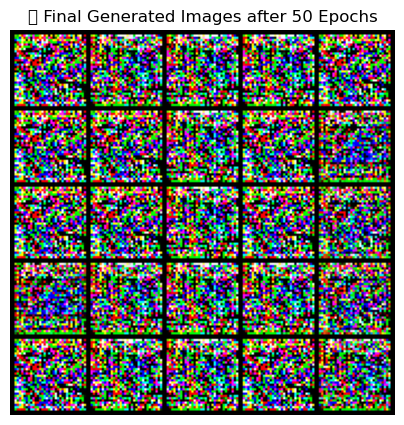

In [66]:
import time

epochs = 50
fixed_noise = torch.randn(64, z_dim, 1, 1).to(device)

for epoch in range(epochs):
    start_time = time.time()

    for batch_idx, (real, _) in enumerate(dataloader):
        real = real.to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size).to(device)
        fake_labels = torch.zeros(batch_size).to(device)

        # ---- Train Discriminator ----
        noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
        fake = gen(noise)

        disc_real = disc(real)
        lossD_real = criterion(disc_real, real_labels)

        disc_fake = disc(fake.detach())
        lossD_fake = criterion(disc_fake, fake_labels)

        lossD = (lossD_real + lossD_fake) / 2
        disc.zero_grad()
        lossD.backward()
        opt_disc.step()

        # ---- Train Generator ----
        output = disc(fake)
        lossG = criterion(output, real_labels)
        gen.zero_grad()
        lossG.backward()
        opt_gen.step()

    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{epochs}]  Loss D: {lossD:.4f}, Loss G: {lossG:.4f}  ⏱️ Time: {epoch_time:.2f} sec")

# Show final output at the end of training
with torch.no_grad():
    fake_images = gen(fixed_noise).detach().cpu()

grid = make_grid(fake_images[:25], normalize=True, nrow=5)
plt.figure(figsize=(5, 5))
plt.imshow(grid.permute(1, 2, 0))
plt.title("🖼️ Final Generated Images after 50 Epochs")
plt.axis('off')
plt.show()


In [67]:
import torch
import torch.nn.functional as F
import numpy as np
from torchvision.models import inception_v3
from scipy.linalg import sqrtm
import torch.nn as nn

# Load pretrained InceptionV3 model
inception_model = inception_v3(pretrained=True, transform_input=False).to(device)
inception_model.fc = nn.Identity()  # Use pool3 features

# Get inception features for a batch of images
def get_inception_features(imgs, model, batch_size=32):
    model.eval()
    features = []

    with torch.no_grad():
        for i in range(0, imgs.size(0), batch_size):
            batch = imgs[i:i+batch_size].to(device)
            batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
            output = model(batch)
            features.append(output.cpu().numpy())

    return np.concatenate(features, axis=0)

# Inception Score
def inception_score(imgs, model, splits=10):
    preds = get_inception_features(imgs, model)
    preds = F.softmax(torch.tensor(preds), dim=1).numpy()
    scores = []

    for i in range(splits):
        part = preds[i * (len(preds)//splits):(i + 1) * (len(preds)//splits)]
        py = np.mean(part, axis=0)
        kl_div = part * (np.log(part + 1e-6) - np.log(py + 1e-6))
        scores.append(np.exp(np.mean(np.sum(kl_div, axis=1))))

    return np.mean(scores), np.std(scores)

# FID Score
def calculate_fid(real_imgs, fake_imgs, model):
    act1 = get_inception_features(real_imgs, model)
    act2 = get_inception_features(fake_imgs, model)
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

# ==== Evaluation ====

# Sample real images from dataloader
real_imgs, _ = next(iter(dataloader))
real_imgs = real_imgs[:64].to(device)

# Generate fake images (assuming you have trained generator `gen`)
with torch.no_grad():
    z = torch.randn(64, 100, 1, 1).to(device)  # Adjust z_dim if different
    gen_imgs = gen(z)

# Evaluate
is_mean, is_std = inception_score(gen_imgs, inception_model)
fid_value = calculate_fid(real_imgs, gen_imgs, inception_model)

print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
print(f"FID Score: {fid_value:.4f}")


C:\Users\Admin\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Inception Score: 1.0154 ± 0.0019
FID Score: 356.0337


In [78]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3, feature_g=64):
        super(Generator, self).__init__()
        self.gen = nn.Sequential(
            # Input: N x z_dim x 1 x 1
            nn.ConvTranspose2d(z_dim, feature_g * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_g * 16),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g * 16, feature_g * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g * 8, feature_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g * 4, feature_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g * 2, feature_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.gen(x)


import time

epochs = 50
fixed_noise = torch.randn(64, z_dim, 1, 1).to(device)

for epoch in range(epochs):
    start_time = time.time()

    for batch_idx, (real, _) in enumerate(dataloader):
        real = real.to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size).to(device)
        fake_labels = torch.zeros(batch_size).to(device)

        # ---- Train Discriminator ----
        noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
        fake = gen(noise)

        disc_real = disc(real)
        lossD_real = criterion(disc_real, real_labels)

        disc_fake = disc(fake.detach())
        lossD_fake = criterion(disc_fake, fake_labels)

        lossD = (lossD_real + lossD_fake) / 2
        disc.zero_grad()
        lossD.backward()
        opt_disc.step()

        # ---- Train Generator ----
        output = disc(fake)
        lossG = criterion(output, real_labels)
        gen.zero_grad()
        lossG.backward()
        opt_gen.step()

    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{epochs}]  Loss D: {lossD:.4f}, Loss G: {lossG:.4f}  ⏱️ Time: {epoch_time:.2f} sec")

# Show final output at the end of training
with torch.no_grad():
    fake_images = gen(fixed_noise).detach().cpu()

grid = make_grid(fake_images[:25], normalize=True, nrow=5)
plt.figure(figsize=(5, 5))
plt.imshow(grid.permute(1, 2, 0))
plt.title("🖼️ Final Generated Images after 50 Epochs")
plt.axis('off')
plt.show()


In [80]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3, feature_d=32):  # Reduce from 64
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            nn.Conv2d(img_channels, feature_d, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(feature_d, feature_d * 2, 4, 2, 1),
            nn.BatchNorm2d(feature_d * 2),
            nn.LeakyReLU(0.2),

            nn.Conv2d(feature_d * 2, feature_d * 4, 4, 2, 1),
            nn.BatchNorm2d(feature_d * 4),
            nn.LeakyReLU(0.2),

            nn.Conv2d(feature_d * 4, 1, 4, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.disc(x)


In [84]:
optimizer_D = torch.optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))  # Slightly higher
optimizer_G = torch.optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))  # Match


In [86]:
real_labels = torch.full((batch_size,), 0.9, device=device)  # Instead of 1.0
fake_labels = torch.full((batch_size,), 0.0, device=device)


Epoch [1/100]  Loss D: 0.1626, Loss G: 10.1243  ⏱️ Time: 29.49 sec
Epoch [2/100]  Loss D: 0.1625, Loss G: 10.3171  ⏱️ Time: 29.68 sec
Epoch [3/100]  Loss D: 0.1626, Loss G: 10.3438  ⏱️ Time: 29.69 sec
Epoch [4/100]  Loss D: 0.1626, Loss G: 10.6906  ⏱️ Time: 29.65 sec
Epoch [5/100]  Loss D: 0.1626, Loss G: 10.3941  ⏱️ Time: 29.55 sec
Epoch [6/100]  Loss D: 0.1626, Loss G: 10.5680  ⏱️ Time: 29.56 sec
Epoch [7/100]  Loss D: 0.1626, Loss G: 10.4775  ⏱️ Time: 29.36 sec
Epoch [8/100]  Loss D: 0.1626, Loss G: 10.3177  ⏱️ Time: 29.42 sec
Epoch [9/100]  Loss D: 0.1626, Loss G: 10.5174  ⏱️ Time: 29.84 sec
Epoch [10/100]  Loss D: 0.1626, Loss G: 10.7618  ⏱️ Time: 30.79 sec
Epoch [11/100]  Loss D: 0.1626, Loss G: 10.6273  ⏱️ Time: 29.86 sec
Epoch [12/100]  Loss D: 0.1626, Loss G: 10.5347  ⏱️ Time: 29.59 sec
Epoch [13/100]  Loss D: 0.1626, Loss G: 10.4263  ⏱️ Time: 29.56 sec
Epoch [14/100]  Loss D: 0.1626, Loss G: 10.3337  ⏱️ Time: 29.78 sec
Epoch [15/100]  Loss D: 0.1626, Loss G: 10.4767  ⏱️ Time:

C:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


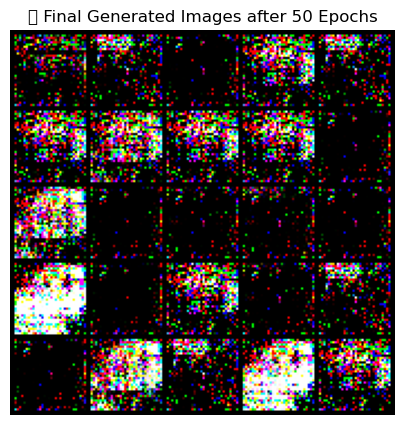

In [83]:
import time

epochs = 100
fixed_noise = torch.randn(64, z_dim, 1, 1).to(device)

for epoch in range(epochs):
    start_time = time.time()

    for batch_idx, (real, _) in enumerate(dataloader):
        real = real.to(device)
        batch_size = real.size(0)

        #real_labels = torch.ones(batch_size).to(device)
        #fake_labels = torch.zeros(batch_size).to(device)
        real_labels = torch.full((batch_size,), 0.9, device=device)  # Instead of 1.0
        fake_labels = torch.full((batch_size,), 0.0, device=device)

        # ---- Train Discriminator ----
        noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
        fake = gen(noise)

        disc_real = disc(real)
        lossD_real = criterion(disc_real, real_labels)

        disc_fake = disc(fake.detach())
        lossD_fake = criterion(disc_fake, fake_labels)

        lossD = (lossD_real + lossD_fake) / 2
        disc.zero_grad()
        lossD.backward()
        opt_disc.step()

        # ---- Train Generator ----
        output = disc(fake)
        lossG = criterion(output, real_labels)
        gen.zero_grad()
        lossG.backward()
        opt_gen.step()

    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{epochs}]  Loss D: {lossD:.4f}, Loss G: {lossG:.4f}  ⏱️ Time: {epoch_time:.2f} sec")

# Show final output at the end of training
with torch.no_grad():
    fake_images = gen(fixed_noise).detach().cpu()

grid = make_grid(fake_images[:25], normalize=True, nrow=5)
plt.figure(figsize=(5, 5))
plt.imshow(grid.permute(1, 2, 0))
plt.title("🖼️ Final Generated Images after 50 Epochs")
plt.axis('off')
plt.show()


In [85]:
import torch
import torch.nn.functional as F
import numpy as np
from torchvision.models import inception_v3
from scipy.linalg import sqrtm
import torch.nn as nn

# Load pretrained InceptionV3 model
inception_model = inception_v3(pretrained=True, transform_input=False).to(device)
inception_model.fc = nn.Identity()  # Use pool3 features

# Get inception features for a batch of images
def get_inception_features(imgs, model, batch_size=32):
    model.eval()
    features = []

    with torch.no_grad():
        for i in range(0, imgs.size(0), batch_size):
            batch = imgs[i:i+batch_size].to(device)
            batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
            output = model(batch)
            features.append(output.cpu().numpy())

    return np.concatenate(features, axis=0)

# Inception Score
def inception_score(imgs, model, splits=10):
    preds = get_inception_features(imgs, model)
    preds = F.softmax(torch.tensor(preds), dim=1).numpy()
    scores = []

    for i in range(splits):
        part = preds[i * (len(preds)//splits):(i + 1) * (len(preds)//splits)]
        py = np.mean(part, axis=0)
        kl_div = part * (np.log(part + 1e-6) - np.log(py + 1e-6))
        scores.append(np.exp(np.mean(np.sum(kl_div, axis=1))))

    return np.mean(scores), np.std(scores)

# FID Score
def calculate_fid(real_imgs, fake_imgs, model):
    act1 = get_inception_features(real_imgs, model)
    act2 = get_inception_features(fake_imgs, model)
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

# ==== Evaluation ====

# Sample real images from dataloader
real_imgs, _ = next(iter(dataloader))
real_imgs = real_imgs[:64].to(device)

# Generate fake images (assuming you have trained generator `gen`)
with torch.no_grad():
    z = torch.randn(64, 100, 1, 1).to(device)  # Adjust z_dim if different
    gen_imgs = gen(z)

# Evaluate
is_mean, is_std = inception_score(gen_imgs, inception_model)
fid_value = calculate_fid(real_imgs, gen_imgs, inception_model)

print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")
print(f"FID Score: {fid_value:.4f}")

C:\Users\Admin\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Inception Score: 1.0239 ± 0.0045
FID Score: 313.9120


In [87]:
# Save Generator and Discriminator weights
torch.save(G.state_dict(), "dcgan_generator.pth")
torch.save(D.state_dict(), "dcgan_discriminator.pth")


In [91]:
torch.save({
    'epoch': epoch,
    'generator_state_dict': G.state_dict(),
    'discriminator_state_dict': D.state_dict(),
    'optimizer_G_state_dict': optimizer_G.state_dict(),
    'optimizer_D_state_dict': optimizer_D.state_dict(),
    'loss_G': lossG,
    'loss_D': lossD,
}, "dcgan_checkpoint.pth")


📅 Epoch [10/100] | 🎯 Loss D: 0.1630 | 🧠 Loss G: 6.6946 | ⏱️ Time: 30.33s
📅 Epoch [20/100] | 🎯 Loss D: 0.1631 | 🧠 Loss G: 7.6133 | ⏱️ Time: 30.46s
📅 Epoch [30/100] | 🎯 Loss D: 0.1627 | 🧠 Loss G: 8.5987 | ⏱️ Time: 30.16s
📅 Epoch [40/100] | 🎯 Loss D: 0.1627 | 🧠 Loss G: 8.6867 | ⏱️ Time: 30.00s
📅 Epoch [50/100] | 🎯 Loss D: 0.1627 | 🧠 Loss G: 8.6926 | ⏱️ Time: 30.20s
📅 Epoch [60/100] | 🎯 Loss D: 0.1876 | 🧠 Loss G: 3.0343 | ⏱️ Time: 30.25s
📅 Epoch [70/100] | 🎯 Loss D: 0.1628 | 🧠 Loss G: 8.9364 | ⏱️ Time: 30.14s
📅 Epoch [80/100] | 🎯 Loss D: 0.1628 | 🧠 Loss G: 9.4732 | ⏱️ Time: 30.46s
📅 Epoch [90/100] | 🎯 Loss D: 0.1626 | 🧠 Loss G: 10.0663 | ⏱️ Time: 30.32s
📅 Epoch [100/100] | 🎯 Loss D: 0.1626 | 🧠 Loss G: 10.4667 | ⏱️ Time: 30.26s


C:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


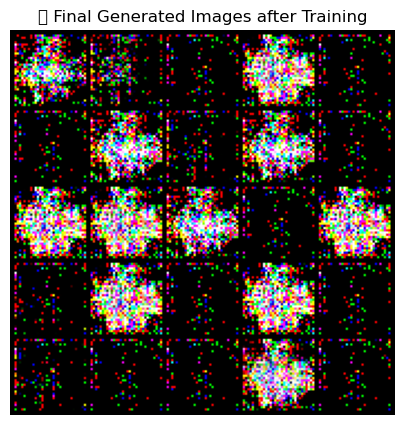

In [88]:
import time
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

epochs = 100
fixed_noise = torch.randn(64, z_dim, 1, 1).to(device)

for epoch in range(epochs):
    start_time = time.time()

    for batch_idx, (real, _) in enumerate(dataloader):
        real = real.to(device)
        batch_size = real.size(0)

        # Smoothed labels
        real_labels = torch.full((batch_size,), 0.9, device=device)
        fake_labels = torch.full((batch_size,), 0.0, device=device)

        # ---- Train Discriminator ----
        noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
        fake = gen(noise)

        disc_real = disc(real)
        lossD_real = criterion(disc_real, real_labels)

        disc_fake = disc(fake.detach())
        lossD_fake = criterion(disc_fake, fake_labels)

        lossD = (lossD_real + lossD_fake) / 2
        disc.zero_grad()
        lossD.backward()
        opt_disc.step()

        # ---- Train Generator ----
        output = disc(fake)
        lossG = criterion(output, real_labels)
        gen.zero_grad()
        lossG.backward()
        opt_gen.step()

    # Print only every 10 epochs
    if (epoch + 1) % 10 == 0:
        epoch_time = time.time() - start_time
        print(f"📅 Epoch [{epoch+1}/{epochs}] | 🎯 Loss D: {lossD:.4f} | 🧠 Loss G: {lossG:.4f} | ⏱️ Time: {epoch_time:.2f}s")

# 🖼️ Show final output after training
with torch.no_grad():
    fake_images = gen(fixed_noise).detach().cpu()

grid = make_grid(fake_images[:25], normalize=True, nrow=5)
plt.figure(figsize=(5, 5))
plt.imshow(grid.permute(1, 2, 0))
plt.title("🖼️ Final Generated Images after Training")
plt.axis('off')
plt.show()


In [90]:
import torch
import torch.nn.functional as F
import torchvision.utils as vutils
from torchvision.models import inception_v3
from scipy.linalg import sqrtm
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------
# Configuration
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 32
os.makedirs("generated_images", exist_ok=True)

# -------------------------
# Load pretrained Inception model
# -------------------------
inception_model = inception_v3(pretrained=True, transform_input=False).to(device)
inception_model.fc = torch.nn.Identity()
inception_model.eval()

# -------------------------
# Generate Images
# -------------------------
def generate_images(generator, num_images=5, conditional=False, class_labels=None):
    generator.eval()
    generated = []

    for i in range(num_images):
        z = torch.randn(1, 100, 1, 1).to(device)

        if conditional:
            label = torch.tensor([class_labels[i]]).to(device)
            img = generator(z, label)
        else:
            img = generator(z)

        generated.append(img)
        vutils.save_image(img.data, f"generated_images/generated_{i}.png", normalize=True)

    return torch.cat(generated, dim=0)

# -------------------------
# Inception Score
# -------------------------
def inception_score(imgs, model, splits=5):
    with torch.no_grad():
        imgs = F.interpolate(imgs, size=(299, 299), mode='bilinear', align_corners=False)
        preds = F.softmax(model(imgs.to(device)), dim=1).cpu().numpy()

    scores = []
    n_part = preds.shape[0] // splits
    for i in range(splits):
        part = preds[i * n_part: (i + 1) * n_part]
        py = np.mean(part, axis=0)
        kl = part * (np.log(part + 1e-6) - np.log(py + 1e-6))
        scores.append(np.exp(np.mean(np.sum(kl, axis=1))))
    return np.mean(scores), np.std(scores)

# -------------------------
# FID Score
# -------------------------
def calculate_fid(real_imgs, fake_imgs, model):
    def get_activations(images):
        activations = []
        with torch.no_grad():
            for i in range(0, images.size(0), batch_size):
                batch = images[i:i + batch_size].to(device)
                batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
                act = model(batch)
                activations.append(act.cpu().numpy())
        return np.concatenate(activations, axis=0)

    act1 = get_activations(real_imgs)
    act2 = get_activations(fake_imgs)

    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)

    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

# -------------------------
# Run Evaluation
# -------------------------

# ⚠️ Update these based on your model and setup
conditional = False  # True for cGAN, False for DCGAN
class_labels = [0, 1, 2, 3, 4]  # Only used if conditional = True
gen.eval()

# Generate 5 synthetic images
gen_imgs = generate_images(gen, num_images=5, conditional=conditional, class_labels=class_labels)

# Get 5 real images from the dataloader
real_imgs, _ = next(iter(dataloader))
real_imgs = real_imgs[:5].to(device)

# Compute Inception Score
is_mean, is_std = inception_score(gen_imgs, inception_model)
print(f"🌟 Inception Score: {is_mean:.4f} ± {is_std:.4f}")

# Compute FID Score
fid = calculate_fid(real_imgs, gen_imgs, inception_model)
print(f"🌟 FID Score: {fid:.4f}")


C:\Users\Admin\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🌟 Inception Score: 1.0000 ± 0.0000
🌟 FID Score: 436.5605


C:\Users\Admin\AppData\Local\Temp\ipykernel_29820\4077079444.py:57: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


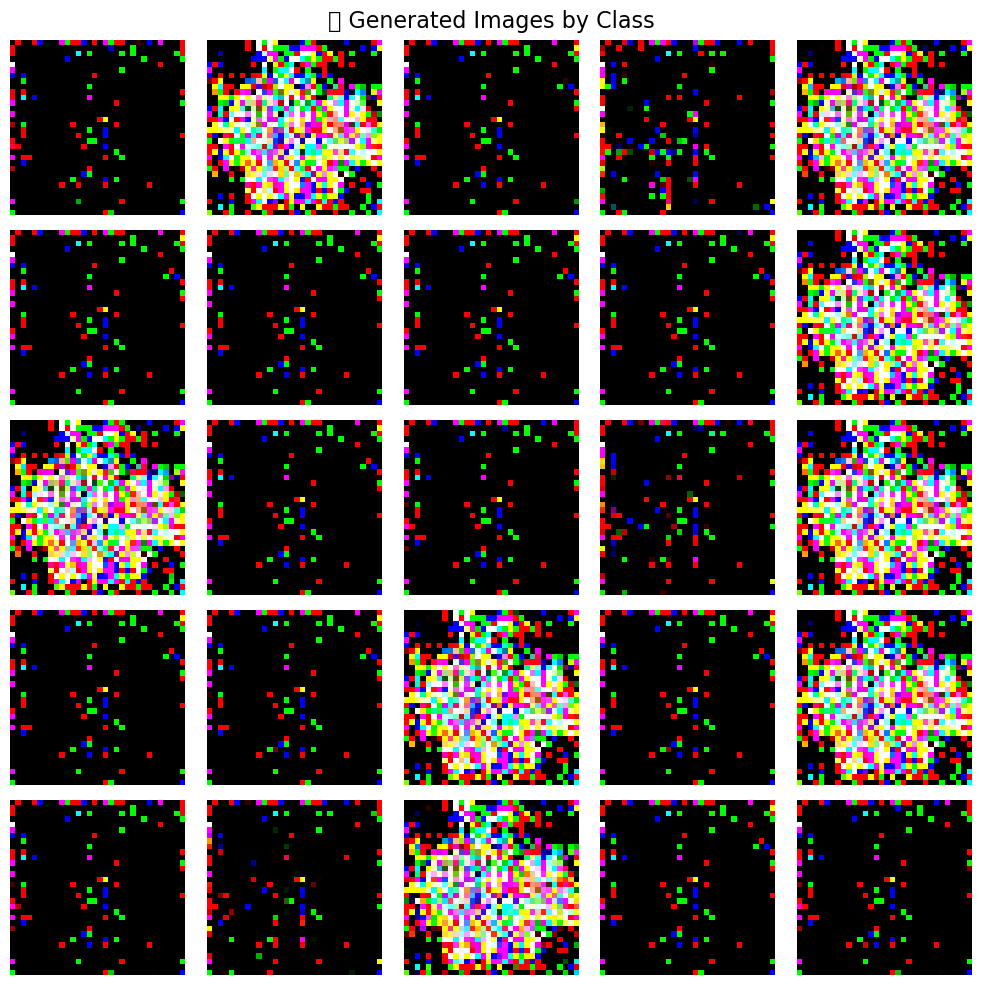

In [98]:
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import os

# -------------------------
# Configuration
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
z_dim = 100
num_classes = 5
images_per_class = 5

os.makedirs("generated_images_per_class", exist_ok=True)

# -------------------------
# Generate and Save 5 Images per Class
# -------------------------
def generate_images_per_class(generator, z_dim, num_classes=5, images_per_class=5):
    generator.eval()
    all_images = []

    with torch.no_grad():
        for class_label in range(num_classes):
            class_images = []
            for i in range(images_per_class):
                z = torch.randn(1, z_dim, 1, 1).to(device)
                label = torch.tensor([class_label], dtype=torch.long).to(device)
                fake = generator(z)
                class_images.append(fake.cpu())

                # Save image
                filename = f"generated_images_per_class/class{class_label}_img{i}.png"
                vutils.save_image(fake, filename, normalize=True)

            all_images.append(torch.cat(class_images, dim=0))

    return all_images  # List of [5 x C x H x W] tensors

# -------------------------
# Display All Generated Images
# -------------------------
def display_generated_grid(all_class_images):
    fig, axes = plt.subplots(num_classes, images_per_class, figsize=(images_per_class * 2, num_classes * 2))

    for row, class_imgs in enumerate(all_class_images):
        for col in range(images_per_class):
            img = class_imgs[col]
            img = img.squeeze().permute(1, 2, 0).numpy()
            img = (img + 1) / 2  # unnormalize from [-1, 1] to [0, 1]
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(f'Class {row}', fontsize=12)

    plt.suptitle("🧠 Generated Images by Class", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

# -------------------------
# Run This
# -------------------------
# ✅ Replace `gen` with your trained conditional generator
all_class_images = generate_images_per_class(gen, z_dim, num_classes=num_classes, images_per_class=images_per_class)
display_generated_grid(all_class_images)


📅 Epoch [50/1000] | 🎯 Loss D: 0.1625 | 🧠 Loss G: 11.3497 | ⏱️ Time: 30.06s
📅 Epoch [100/1000] | 🎯 Loss D: 0.1626 | 🧠 Loss G: 11.1101 | ⏱️ Time: 31.38s
📅 Epoch [150/1000] | 🎯 Loss D: 0.1626 | 🧠 Loss G: 11.4806 | ⏱️ Time: 30.46s
📅 Epoch [200/1000] | 🎯 Loss D: 0.1626 | 🧠 Loss G: 12.2839 | ⏱️ Time: 32.62s
📅 Epoch [250/1000] | 🎯 Loss D: 0.1626 | 🧠 Loss G: 10.8255 | ⏱️ Time: 30.28s
📅 Epoch [300/1000] | 🎯 Loss D: 0.1626 | 🧠 Loss G: 11.2943 | ⏱️ Time: 30.33s
📅 Epoch [350/1000] | 🎯 Loss D: 0.1626 | 🧠 Loss G: 10.5119 | ⏱️ Time: 30.22s
📅 Epoch [400/1000] | 🎯 Loss D: 0.1626 | 🧠 Loss G: 11.9336 | ⏱️ Time: 30.68s
📅 Epoch [450/1000] | 🎯 Loss D: 0.1625 | 🧠 Loss G: 12.6179 | ⏱️ Time: 30.51s
📅 Epoch [500/1000] | 🎯 Loss D: 0.1625 | 🧠 Loss G: 13.3533 | ⏱️ Time: 34.48s
📅 Epoch [550/1000] | 🎯 Loss D: 0.1625 | 🧠 Loss G: 13.7212 | ⏱️ Time: 30.83s
📅 Epoch [600/1000] | 🎯 Loss D: 0.1625 | 🧠 Loss G: 13.3944 | ⏱️ Time: 31.13s
📅 Epoch [650/1000] | 🎯 Loss D: 0.1626 | 🧠 Loss G: 10.4154 | ⏱️ Time: 30.29s
📅 Epoch [700/

C:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


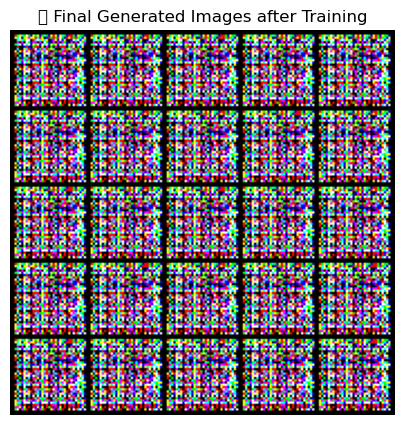

In [100]:
import time
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

epochs = 1000
fixed_noise = torch.randn(64, z_dim, 1, 1).to(device)

for epoch in range(epochs):
    start_time = time.time()

    for batch_idx, (real, _) in enumerate(dataloader):
        real = real.to(device)
        batch_size = real.size(0)

        # Smoothed labels
        real_labels = torch.full((batch_size,), 0.9, device=device)
        fake_labels = torch.full((batch_size,), 0.0, device=device)

        # ---- Train Discriminator ----
        noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
        fake = gen(noise)

        disc_real = disc(real)
        lossD_real = criterion(disc_real, real_labels)

        disc_fake = disc(fake.detach())
        lossD_fake = criterion(disc_fake, fake_labels)

        lossD = (lossD_real + lossD_fake) / 2
        disc.zero_grad()
        lossD.backward()
        opt_disc.step()

        # ---- Train Generator ----
        output = disc(fake)
        lossG = criterion(output, real_labels)
        gen.zero_grad()
        lossG.backward()
        opt_gen.step()

    # Print only every 10 epochs
    if (epoch + 1) % 50 == 0:
        epoch_time = time.time() - start_time
        print(f"📅 Epoch [{epoch+1}/{epochs}] | 🎯 Loss D: {lossD:.4f} | 🧠 Loss G: {lossG:.4f} | ⏱️ Time: {epoch_time:.2f}s")

# 🖼️ Show final output after training
with torch.no_grad():
    fake_images = gen(fixed_noise).detach().cpu()

grid = make_grid(fake_images[:25], normalize=True, nrow=5)
plt.figure(figsize=(5, 5))
plt.imshow(grid.permute(1, 2, 0))
plt.title("🖼️ Final Generated Images after Training")
plt.axis('off')
plt.show()

In [104]:
import torch

# Update the paths accordingly
checkpoint_path = "C:\\Users\\Admin\\Downloads\\dcgan_checkpoint.pth"
generator_path = "C:\\Users\\Admin\\Downloads\\dcgan_generator.pth"
discriminator_path = "C:\\Users\\Admin\\Downloads\\dcgan_discriminator.pth"

def try_load(path, name):
    try:
        data = torch.load(path, map_location='cpu')
        print(f"{name}: ✅ Loaded successfully")
        return data
    except Exception as e:
        print(f"{name}: ❌ Failed to load - {e}")
        return None

chkpt = try_load(checkpoint_path, "Checkpoint")
gen = try_load(generator_path, "Generator")
disc = try_load(discriminator_path, "Discriminator")


Checkpoint: ✅ Loaded successfully
Generator: ✅ Loaded successfully
Discriminator: ✅ Loaded successfully


C:\Users\Admin\AppData\Local\Temp\ipykernel_29820\3915140204.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(path, map_location='cpu')
